# Store-memory sandbox — late-season flow response to initial stores

**Question.** How do late-season (JJAS) streamflows respond to the size of an initial
store, and how long does the anomaly persist?

**Two experiments** (each member = same warm state *except* one perturbed store):

| Domain | Store varied | Sweep | Target HRUs |
|--------|--------------|-------|-------------|
| **Tuolumne** (elevAspect) | initial high-elevation SWE (persistent snow/firn) | 0 → 10 m water-equiv, 11 levels | single high **north-facing** HRU (**hru 2**: 3679 m, aspect 348°) |
| **East** (elevAspect, bigBuckt) | aquifer recession timescale τ + initial storage | τ ∈ 1 mo → 5 yr, log-spaced | flat valley HRU (**hru 25**) |

**Fixed across all members**
- **Period:** 2014-10-01 → 2019-09-30 (WY2015–WY2019), real observed forcing.
- **Warm state:** extracted at **2014-10-01 00:00** from each basin's long-term run, then perturbed.
- Oct-1 start ⇒ near-bare ground / small aquifer, so the injected store is a clean perturbation.

**Anomaly** for member *m*: `A_m(t) = Q_m(t) − Q_baseline(t)`, where baseline = unperturbed
warm state. We track (a) peak late-season anomaly vs. store size, and (b) the e-folding decay
time of the anomaly across water years.

---

### ⚠️ Correctness notes baked into this notebook
1. **`scalarSWE` is kg m⁻² = mm water.** "10 m SWE" = 10 000 mm. Specify SWE in **metres water** below; code converts.
2. **East τ lives in `trialParams.nc`, NOT `basinParamInfo.txt`.** trialParams overrides
   `aquiferBaseflowRate / aquiferScaleFactor / aquiferBaseflowExp` and silently wins. We edit trialParams.
3. **Injecting snow into an `nSnow=0` warm state** requires adding a snow *layer* (resize
   `midToto`/`ifcToto`, snow-first ordering, recompute `iLayerHeight`) — not just setting `scalarSWE`.
   Smoke-test one member (§4) before trusting a sweep — SUMMA may reject a too-thick single layer.

## 0 · Config & knobs — *the sandbox dials live here*

In [1]:
from __future__ import annotations
from pathlib import Path
import shutil, subprocess, re
from calendar import monthrange
import numpy as np, pandas as pd, xarray as xr, netCDF4 as nc4
import matplotlib.pyplot as plt

SCRATCH = Path("/scratch/dlhogan/ess-project-data")

# ── period (fixed for every member) ──────────────────────────────────────────
SIM_START      = "2014-10-01 00:00"
SIM_END        = "2019-09-30 23:00"
WARM_STATE_TS  = pd.Timestamp("2014-10-01 00:00")      # extract this slice from long-term run
FORCING_MONTHS = pd.date_range("2014-10-01", "2019-09-01", freq="MS")   # 201410 … 201909

SUMMA_EXE = "summa"

# ── domains: point these at each basin's best-sim settings + long-term output ─
# 'longterm' is the multi-year SUMMA output the warm state is sliced from.
# Set to None to instead reuse an existing warmState.nc via 'warm_fallback'.
DOMAINS = {
    "Tuolumne": {
        "data_dir": "domain_Tuolumne_River_distributed_elevAspect",
        "settings": SCRATCH/"calibration/bestruns/Tuolumne_River_baseline_wbias10_1981_2025/run",  # FULL config that produced the warm state (params+attributes+decisions+outputControl)
        "longterm": SCRATCH/"calibration/bestruns/Tuolumne_River_baseline_wbias10_1981_2025/run/out/baseline_timestep.nc",   # e.g. SCRATCH/".../simulations/longterm/output/<run>_timestep.nc"
        "warm_fallback": SCRATCH/"calibration/bestruns/Tuolumne_River_baseline_wbias10_1981_2025/run/coldState.nc",  # cold-start fallback (matches settings)
        "forcing":  SCRATCH/"calibration/bestruns/Tuolumne_River_baseline_wbias10_1981_2025/run/forcing",  # MUST match the long-term run (temp-adjusted) — NOT SUMMA_input
    },
    "East": {
        "data_dir": "domain_East_River_distributed_elevAspect",
        "settings": SCRATCH/"calibration/bestruns/East_River_baseline_1981_2025/run",  # FULL config that produced the warm state
        "longterm": SCRATCH/"calibration/bestruns/East_River_baseline_1981_2025/run/out/baseline_timestep.nc",
        "warm_fallback": SCRATCH/"calibration/bestruns/East_River_baseline_1981_2025/run/coldState.nc",  # cold-start fallback (matches settings)
        "forcing":  SCRATCH/"calibration/bestruns/East_River_baseline_1981_2025/run/forcing",  # MUST match the long-term run — NOT SUMMA_input
    },
}

# ── experiment defaults (edit freely) ────────────────────────────────────────
EXP_ROOT = SCRATCH/"domain_East_River_distributed_elevAspect"/"simulations"/"store_memory_sandbox"  # rewritten per-domain below

# Tuolumne snowpatch sweep
TUO_SWE_LEVELS_M = np.linspace(0, 10, 11)     # metres water-equivalent
TUO_SNOWPATCH_HRU = 2                           # single high north-facing HRU (elev 3679 m, aspect 348 deg)
SNOW_DENSITY     = 500.0                        # kg/m3 (firn / persistent snow)
SNOW_TEMP_K      = 272.15                       # cold, dry persistent pack
SNOW_N_LAYERS    = 5                            # start simple; bump if SUMMA rejects thick layer
SNOWPATCH_SOIL_TEMP_K = 273.15                 # cold ground under the patch (0 C) - stops bottom-melt; None = leave coldState 283 K
SNOWPATCH_SOIL_ICE    = 0.0                    # volumetric ice frozen into patch soil (0=none; e.g. 0.3). Use with soil_temp_k<273.15
# ── snowpatch albedo floor (TOGGLE) ──────────────────────────────────────────
# Under the active alb_method=varDecay, the aged-snow albedo floor is set by the spectral bands
# albedoMinVisible (0.75) + albedoMinNearIR (localParamInfo default 0.30); raising NIR lifts the
# floor and slows summer melt. (albedoMinWinter/Spring are conDecay params -> INERT here.)
# Applied PER-HRU in trialParams.nc (separate file from warmState -> never touched by the warm-state
# adjustment). Lever saturates ~0.70 because albedoMinVisible caps it (0.70 == 0.75 exactly).
#   None -> leave default 0.30 (floor ~0.52, 15 m pack MELTS OUT by WY2019)
#   0.70 -> floor ~0.72, firn/glacieret regime: deep-snow years (2017) RECOVER, dry years decay
TUO_ALBEDO_NIR_FLOOR   = 0.70                  # set None to disable; 0.70 = max-persistence (recovery regime)
TUO_ALBEDO_NIR_DEFAULT = 0.30                  # localParamInfo default written to every OTHER HRU

# East aquifer sweep
EAST_TAU_DAYS    = np.geomspace(30, 5*365, 10)  # 1 month → 5 years, log-spaced
EAST_FLAT_HRU    = 25                            # valley-floor HRU (slope 0.06, 79 km2)
EAST_INIT_STOR_M = 10.0                           # "larger initial storage state" (m)
EAST_LINEARIZE   = False                         # True: force exp=1 so tau = Scale/Rate exactly
                                                 # False: keep calibrated exp, solve Rate at S_ref=S0

# late-season window for the anomaly metric
LATE_SEASON = (8, 9)   # Jun–Sep inclusive
print("Config loaded. Period:", SIM_START, "→", SIM_END)

Config loaded. Period: 2014-10-01 00:00 → 2019-09-30 23:00


## 1 · Build & inspect the base (unperturbed) warm state

If `longterm` is set, we slice `WARM_STATE_TS` from the long-term run (reusing the seasonal
extractor's variable map). Otherwise we fall back to an existing `warmState.nc`. Either way
this is the **baseline** every member starts from.

In [2]:
def extract_warmstate(longterm_nc: Path, cold_nc: Path, out: Path, ts=WARM_STATE_TS) -> Path:
    """Slice `ts` from a long-term SUMMA output into a coldState-shaped warmState.nc.

    HYBRID: scalar states (SWE, aquifer storage, canopy) come from the long-term run where
    available; ANY variable the output lacks — notably the soil-layer profile (mLayerTemp,
    mLayerVolFrac*, mLayerMatricHead), which most outputControl.txt configs don't save —
    falls back to the domain coldState.nc (a physical equilibrium start), NOT zeros.
    The anomaly analysis subtracts a shared baseline, so this generic soil init cancels."""
    SCAL = [("scalarCanopyIce","scalarCanopyIce_mean"),("scalarCanopyLiq","scalarCanopyLiq_mean"),
            ("scalarSnowDepth","scalarSnowDepth_mean"),("scalarSWE","scalarSWE"),
            ("scalarSfcMeltPond","scalarSfcMeltPond_mean"),("scalarAquiferStorage","scalarAquiferStorage_mean"),
            ("scalarCanopyTemp","scalarCanopyTemp_mean"),("scalarCanairTemp","scalarCanairTemp_mean")]
    LAYER = [("mLayerTemp","mLayerTemp_mean"),("mLayerVolFracIce","mLayerVolFracIce_mean"),
             ("mLayerVolFracLiq","mLayerVolFracLiq_mean"),("mLayerMatricHead","mLayerMatricHead_mean")]
    lt, cold = xr.open_dataset(longterm_nc), xr.open_dataset(cold_nc)
    idx = pd.DatetimeIndex(lt.time.values).get_indexer([ts], method="nearest")[0]
    lt_t = lt.isel(time=idx)
    actual = pd.Timestamp(lt.time.values[idx])
    if abs((actual - ts).total_seconds()) > 7200:
        print(f"  WARNING: nearest long-term time {actual} is >2 h from target {ts}")
    nhru = int(cold.sizes["hru"]); nsoil = int(cold["nSoil"].values.flat[0]); nmid = nsoil; nifc = nsoil+1
    out.parent.mkdir(parents=True, exist_ok=True)
    def pick(name):
        if name and name in lt_t: return name
        f = name.removesuffix("_mean") if name else None
        return f if (f and f in lt_t) else None
    def cold_scalar(cs):
        return np.array(cold[cs].values).ravel() if cs in cold else None
    missing = []
    with nc4.Dataset(out, "w") as d:
        for n,s in [("hru",nhru),("scalarv",1),("midSoil",nsoil),("midToto",nmid),("ifcToto",nifc)]:
            d.createDimension(n,s)
        d.createVariable("hruId","i4",("hru",))[:] = cold["hruId"].values
        for n,val in [("nSoil",nsoil),("nSnow",0)]: d.createVariable(n,"i4",("scalarv","hru"))[:] = val
        d.createVariable("dt_init","f8",("scalarv","hru"))[:] = 3600.0
        for cs,ltn in SCAL:
            v = d.createVariable(cs,"f8",("scalarv","hru")); a = pick(ltn)
            if a is not None:
                arr = np.atleast_1d(lt_t[a].values).ravel()
                v[0,:] = arr if arr.size==nhru else np.full(nhru, float(np.nanmean(arr)))
            else:
                cs_arr = cold_scalar(cs)
                v[0,:] = cs_arr if cs_arr is not None else 0.0
                missing.append(cs)
        d.createVariable("scalarSnowAlbedo","f8",("scalarv","hru"))[:] = (
            cold_scalar("scalarSnowAlbedo") if "scalarSnowAlbedo" in cold else 0.85)
        for cs,ltn in LAYER:
            dim = "midSoil" if cs=="mLayerMatricHead" else "midToto"
            v = d.createVariable(cs,"f8",(dim,"hru")); a = pick(ltn)
            if a is not None:
                arr = np.atleast_2d(lt_t[a].values); rows = v.shape[0]
                if arr.shape[1]!=nhru: arr = arr.T
                v[:min(rows,arr.shape[0]),:] = arr[:rows,:]
            else:
                src = np.atleast_2d(cold[cs].values)
                if src.shape[1]!=nhru: src = src.T
                v[:] = src[:v.shape[0],:]; missing.append(cs)
        for cs,dim in [("mLayerDepth","midToto"),("iLayerHeight","ifcToto")]:
            exp = nmid if dim=="midToto" else nifc
            arr = np.atleast_2d(cold[cs].values)
            if arr.shape[1]!=nhru: arr = arr.T
            d.createVariable(cs,"f8",(dim,"hru"))[:] = arr[:exp,:]
        d.History = f"hybrid warmState: scalars from {longterm_nc.name} @ {actual}; soil profile from {cold_nc.name}"
    if missing: print(f"  [{out.parent.name}] from coldState (not in long-term output): {sorted(set(missing))}")
    lt.close(); cold.close()
    return out


def get_base_warmstate(dom: str) -> Path:
    cfg = DOMAINS[dom]
    exp = SCRATCH/cfg["data_dir"]/"simulations"/"store_memory_sandbox"
    base = exp/"base_warmState.nc"; base.parent.mkdir(parents=True, exist_ok=True)
    cold = cfg["settings"]/"coldState.nc"
    if cfg["longterm"] is not None:
        extract_warmstate(cfg["longterm"], cold, base)
    else:
        print(f"  [{dom}] no long-term run set -> cold start from warm_fallback (not spun-up)")
        shutil.copy(cfg["warm_fallback"], base)
    _assert_forcing_matches_longterm(dom)
    return base

def _assert_forcing_matches_longterm(dom: str):
    """Enforce that experiment forcing == the forcing the long-term run (warm-state source)
    used. A ~1 K mismatch here made snow accumulate year-over-year — never again."""
    cfg = DOMAINS[dom]
    if cfg["longterm"] is None:
        return
    lt_forcing = cfg["longterm"].parent.parent / "forcing"   # <run>/run/out/*.nc -> <run>/run/forcing
    ym = pd.Timestamp(SIM_START).strftime("%Y%m")
    exp_f = sorted(Path(cfg["forcing"]).glob(f"*_{ym}.nc"))
    lt_f  = sorted(lt_forcing.glob(f"*_{ym}.nc"))
    if not exp_f or not lt_f:
        print(f"  [{dom}] forcing-check SKIPPED (no {ym} file in one of the dirs)"); return
    a = nc4.Dataset(exp_f[0]); b = nc4.Dataset(lt_f[0])
    t1 = np.array(a["airtemp"][:]); t2 = np.array(b["airtemp"][:]); a.close(); b.close()
    d = float(np.nanmax(np.abs(t1 - t2))) if t1.shape == t2.shape else 9e9
    if d > 1e-6:
        raise ValueError(
            f"[{dom}] experiment forcing != long-term forcing "
            f"(airtemp max|diff|={d:.3g} K @ {ym}). Set DOMAINS['{dom}']['forcing'] = {lt_forcing}")
    print(f"  [{dom}] forcing matches long-term run OK ({ym})")

  [store_memory_sandbox] from coldState (not in long-term output): ['mLayerMatricHead', 'mLayerTemp', 'mLayerVolFracIce', 'mLayerVolFracLiq', 'scalarCanairTemp', 'scalarCanopyIce', 'scalarCanopyLiq', 'scalarCanopyTemp', 'scalarSfcMeltPond', 'scalarSnowDepth']
  [Tuolumne] forcing matches long-term run OK (201410)
  [store_memory_sandbox] from coldState (not in long-term output): ['mLayerMatricHead', 'mLayerTemp', 'mLayerVolFracIce', 'mLayerVolFracLiq', 'scalarCanairTemp', 'scalarCanopyIce', 'scalarCanopyLiq', 'scalarCanopyTemp', 'scalarSfcMeltPond', 'scalarSnowDepth']
  [East] forcing matches long-term run OK (201410)


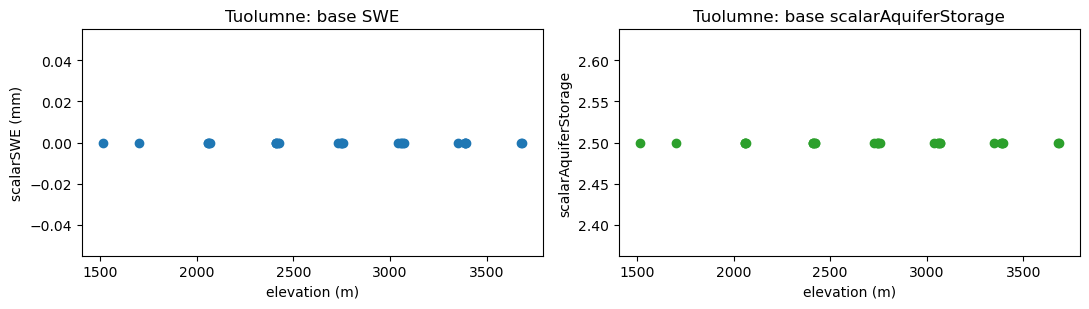

Tuolumne: 28 HRUs | SWE 0–0 mm | scalarAquiferStorage 2.5–2.5


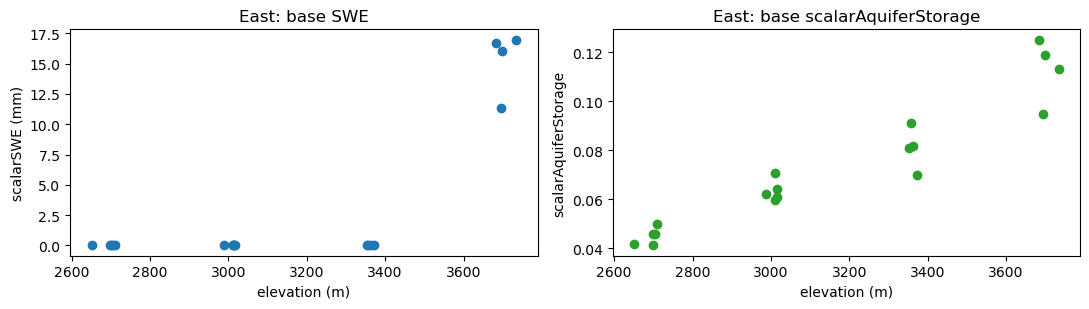

East: 18 HRUs | SWE 0.000576–17 mm | scalarAquiferStorage 0.0411–0.125


In [3]:
def inspect_warmstate(p: Path, dom: str):
    d = nc4.Dataset(p)
    hid  = d["hruId"][:].ravel(); nhru = hid.size
    att  = nc4.Dataset(DOMAINS[dom]["settings"]/"attributes.nc")
    elev = np.array(att["elevation"][:]).ravel(); att.close()

    def per_hru(name):
        """One value per HRU. Layer fields (midToto x hru) are averaged over layers so the
        result is always length nhru (avoids 'x and y must be the same size' in scatter)."""
        a = np.array(d[name][:])
        return a.ravel() if a.size == nhru else np.nanmean(a.reshape(-1, nhru), axis=0)

    swe = per_hru("scalarSWE")
    # second panel = the "other store": aquifer storage if the file has it, else mean soil liquid
    aq_name = "scalarAquiferStorage" if "scalarAquiferStorage" in d.variables else "mLayerVolFracLiq"
    aq = per_hru(aq_name)

    fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
    ax[0].scatter(elev, swe, c="tab:blue");  ax[0].set(xlabel="elevation (m)", ylabel="scalarSWE (mm)", title=f"{dom}: base SWE")
    ax[1].scatter(elev, aq,  c="tab:green"); ax[1].set(xlabel="elevation (m)", ylabel=aq_name, title=f"{dom}: base {aq_name}")
    plt.tight_layout(); plt.show()
    d.close()
    print(f"{dom}: {nhru} HRUs | SWE {swe.min():.3g}–{swe.max():.3g} mm | {aq_name} {aq.min():.3g}–{aq.max():.3g}")

BASE = {dom: get_base_warmstate(dom) for dom in DOMAINS}
for dom in DOMAINS: inspect_warmstate(BASE[dom], dom)

## 2 · Perturbation functions

Each writes a **new** `warmState.nc` (and, for East, a patched `trialParams.nc`) — the base file
is never mutated.

In [4]:
RHO_ICE = 917.0

def inject_snowpatch(base_ws: Path, out_ws: Path, target_hrus, swe_m: float,
                     rho=SNOW_DENSITY, temp_k=SNOW_TEMP_K, n_layers=SNOW_N_LAYERS,
                     soil_temp_k=SNOWPATCH_SOIL_TEMP_K, soil_ice=SNOWPATCH_SOIL_ICE):
    """Write a warmState with `swe_m` metres-water snow on `target_hrus` (1-based hruIds).
    Snow layers are prepended to the soil column (midToto/ifcToto resized, iLayerHeight recomputed).

    Cold ground: on `target_hrus` the SOIL temperature is set to `soil_temp_k` (default 273.15 K =
    0 C) and ice fraction to `soil_ice`, so the persistent pack does not melt from below on the
    283 K (10 C) coldState default. Applied for ALL swe_m — including the swe=0 baseline — so the
    ground state is identical across a sweep and only the snow mass varies (clean attribution).
    Set soil_temp_k=None to leave the coldState soil untouched."""
    src = nc4.Dataset(base_ws)
    hid = src["hruId"][:].ravel(); nhru = hid.size
    nsoil = int(np.array(src["nSoil"][:]).ravel()[0])
    tgt = np.isin(hid, np.atleast_1d(target_hrus))
    swe_mm = swe_m * 1000.0
    add_snow = (swe_m > 0) and bool(tgt.any())

    nsnow = (np.where(tgt, n_layers, 0) if add_snow else np.zeros(nhru, int)).astype("i4")
    max_snow = int(nsnow.max())
    nmid = max_snow + nsoil; nifc = nmid + 1
    if add_snow:
        depth_tot = swe_mm / rho                  # total snow depth (m)
        volice = rho / RHO_ICE                     # consistent: SWE = volice*RHO_ICE*depth

    def base2d(name):
        a = np.atleast_2d(np.array(src[name][:]))
        return (a if a.shape[1] == nhru else a.T)[:nsoil].copy()
    soilT   = base2d("mLayerTemp")
    soilIce = base2d("mLayerVolFracIce")
    soilLiq = base2d("mLayerVolFracLiq")
    soilDep = base2d("mLayerDepth")
    matric  = base2d("mLayerMatricHead")          # midSoil, unchanged

    # cold-ground override on the patch HRU(s)
    if soil_temp_k is not None and tgt.any():
        soilT[:, tgt] = soil_temp_k
    if soil_ice and soil_ice > 0 and tgt.any():
        add = np.minimum(soil_ice, soilLiq[:, tgt])   # freeze available liquid -> ice
        soilIce[:, tgt] = soilIce[:, tgt] + add
        soilLiq[:, tgt] = soilLiq[:, tgt] - add

    T   = np.zeros((nmid, nhru)); Ice = np.zeros((nmid, nhru))
    Liq = np.zeros((nmid, nhru)); Dep = np.zeros((nmid, nhru))
    iH  = np.zeros((nifc, nhru))
    for h in range(nhru):
        ns = int(nsnow[h])
        if ns:
            dl = depth_tot / ns
            T[:ns, h] = temp_k; Ice[:ns, h] = volice; Liq[:ns, h] = 0.0; Dep[:ns, h] = dl
        T[ns:ns+nsoil, h]   = soilT[:, h]
        Ice[ns:ns+nsoil, h] = soilIce[:, h]
        Liq[ns:ns+nsoil, h] = soilLiq[:, h]
        Dep[ns:ns+nsoil, h] = soilDep[:, h]
        depths = Dep[:ns+nsoil, h]
        top = -depths[:ns].sum()                   # 0 at ground surface, snow above (negative)
        heights = top + np.concatenate([[0.0], np.cumsum(depths)])
        iH[:heights.size, h] = heights

    with nc4.Dataset(out_ws, "w") as d:
        for n, s in [("hru",nhru),("scalarv",1),("midSoil",nsoil),("midToto",nmid),("ifcToto",nifc)]:
            d.createDimension(n, s)
        d.createVariable("hruId","i4",("hru",))[:] = hid
        d.createVariable("nSoil","i4",("scalarv","hru"))[:] = nsoil
        d.createVariable("nSnow","i4",("scalarv","hru"))[0,:] = nsnow
        d.createVariable("dt_init","f8",("scalarv","hru"))[:] = 3600.0
        for name in ["scalarCanopyIce","scalarCanopyLiq","scalarSfcMeltPond",
                     "scalarAquiferStorage","scalarCanopyTemp","scalarCanairTemp"]:
            d.createVariable(name,"f8",("scalarv","hru"))[0,:] = np.array(src[name][:]).ravel()
        swe_v = np.array(src["scalarSWE"][:]).ravel()
        dep_v = np.array(src["scalarSnowDepth"][:]).ravel()
        alb_v = np.array(src["scalarSnowAlbedo"][:]).ravel()
        if add_snow:
            swe_v[tgt] = swe_mm; dep_v[tgt] = depth_tot; alb_v[tgt] = 0.60
        d.createVariable("scalarSWE","f8",("scalarv","hru"))[0,:] = swe_v
        d.createVariable("scalarSnowDepth","f8",("scalarv","hru"))[0,:] = dep_v
        d.createVariable("scalarSnowAlbedo","f8",("scalarv","hru"))[0,:] = alb_v
        d.createVariable("mLayerTemp","f8",("midToto","hru"))[:] = T
        d.createVariable("mLayerVolFracIce","f8",("midToto","hru"))[:] = Ice
        d.createVariable("mLayerVolFracLiq","f8",("midToto","hru"))[:] = Liq
        d.createVariable("mLayerDepth","f8",("midToto","hru"))[:] = Dep
        d.createVariable("mLayerMatricHead","f8",("midSoil","hru"))[:] = matric
        d.createVariable("iLayerHeight","f8",("ifcToto","hru"))[:] = iH
        d.History = (f"snowpatch: {swe_m} m SWE on hrus {list(np.atleast_1d(target_hrus))}; "
                     f"patch soil_temp_k={soil_temp_k} soil_ice={soil_ice}")
    src.close(); return out_ws

In [5]:
def make_albedo_trial(base_trial: Path, out_trial: Path, target_hru,
                      nir_floor: float, nir_default: float = None) -> Path:
    """Copy trialParams.nc and add a PER-HRU `albedoMinNearIR` floor on `target_hru`.

    Why NIR: alb_method=varDecay sets the aged-snow albedo floor from the spectral bands
    albedoMinVisible (0.75) + albedoMinNearIR (localParamInfo default 0.30). Raising NIR lifts
    the whole floor and slows summer melt. (albedoMinWinter/Spring are conDecay params -> INERT.)

    Because trialParams overrides localParamInfo for EVERY HRU it is dimensioned over, we write
    `nir_default` (0.30) to every OTHER HRU so ONLY the patch changes. This lives entirely in
    trialParams -> it is INDEPENDENT of warmState.nc and never clobbered by inject_snowpatch.
    See [[summa-trialparams-overrides-localparaminfo]] — trialParams has no bounds check."""
    nir_default = TUO_ALBEDO_NIR_DEFAULT if nir_default is None else nir_default
    shutil.copy(base_trial, out_trial)
    with nc4.Dataset(out_trial, "a") as t:
        hid = np.array(t["hruId"][:]).ravel()
        m = (hid == target_hru)
        v = (t.createVariable("albedoMinNearIR", "f8", ("hru",))
             if "albedoMinNearIR" not in t.variables else t["albedoMinNearIR"])
        v[:] = np.where(m, nir_floor, nir_default).astype(float)
        print(f"  albedoMinNearIR: hru{target_hru}={nir_floor:.2f}  others={nir_default:.2f}"
              f"  -> {out_trial.name}")
    return out_trial

In [6]:
def set_aquifer_memory(base_ws: Path, base_trial: Path, out_ws: Path, out_trial: Path,
                       target_hrus, tau_days: float, init_stor_m: float,
                       linearize=EAST_LINEARIZE):
    '''Set initial aquifer storage on `target_hrus` and rewrite trialParams so the
    column baseflow recession timescale ≈ `tau_days`.
      bigBuckt:  Q = Rate * (S/Scale)^exp     (localColumn)  ⇒  tau = S/Q
      linear (exp=1):     tau = Scale/Rate            → Rate = Scale/(tau)
      nonlinear (keep exp): tau = Scale^exp/(Rate S0^{exp-1}) at S_ref=S0
    Returns (out_ws, out_trial).'''
    tau_s = tau_days * 86400.0
    # 1) storage state
    src = nc4.Dataset(base_ws); hid = src["hruId"][:].ravel()
    tgt = np.isin(hid, np.atleast_1d(target_hrus))
    with nc4.Dataset(base_ws) as _s, nc4.Dataset(out_ws, "w") as d:
        for n, dim in _s.dimensions.items(): d.createDimension(n, len(dim))
        for name, var in _s.variables.items():
            v = d.createVariable(name, var.datatype, var.dimensions)
            v[:] = var[:]
            if name == "scalarAquiferStorage":
                arr = np.array(var[:]); arr.ravel()[tgt] = init_stor_m; v[:] = arr
    src.close()
    # 2) trialParams recession
    shutil.copy(base_trial, out_trial)
    with nc4.Dataset(out_trial, "a") as t:
        scale = np.array(t["aquiferScaleFactor"][:]).astype(float)
        expo  = np.array(t["aquiferBaseflowExp"][:]).astype(float)
        rate  = np.array(t["aquiferBaseflowRate"][:]).astype(float)
        thid  = t["hruId"][:].ravel(); m = np.isin(thid, np.atleast_1d(target_hrus))
        if linearize:
            expo_new = np.where(m.reshape(expo.shape), 1.0, expo)
            rate_new = np.where(m.reshape(rate.shape), scale/tau_s, rate)
            t["aquiferBaseflowExp"][:] = expo_new
        else:
            S0 = init_stor_m
            rate_target = scale**expo / (tau_s * S0**(expo-1.0))
            rate_new = np.where(m.reshape(rate.shape), rate_target, rate)
        t["aquiferBaseflowRate"][:] = rate_new
    return out_ws, out_trial

## 3 · Build a member run directory

Mirrors `RunSetupManager` in `synthetic_extended_runs.py`: symlink the shared settings, drop in the
perturbed `warmState.nc` (+ `trialParams.nc` for East), list the real Oct-2014→Sep-2019 forcing,
and write a `fileManager.txt` for the period.

In [7]:
SETTINGS_LINK = ["attributes.nc","modelDecisions.txt","outputControl.txt",
                 "localParamInfo.txt","basinParamInfo.txt",
                 "TBL_VEGPARM.TBL","TBL_SOILPARM.TBL","TBL_GENPARM.TBL","TBL_MPTABLE.TBL"]

def forcing_prefix(dom):
    files = sorted(DOMAINS[dom]["forcing"].glob("*.nc"))
    for f in files:
        m = re.match(r"^(.+_)(\d{6})$", f.stem)
        if m: return m.group(1)
    raise FileNotFoundError(f"no YYYYMM forcing in {DOMAINS[dom]['forcing']}")

def build_member(dom, name, warmstate: Path, trialparams: Path|None=None) -> Path:
    cfg = DOMAINS[dom]; sett = cfg["settings"]
    tmzone = "localTime"
    fm_src = sett/"fileManager.txt"
    if fm_src.exists():
        for _ln in fm_src.read_text().splitlines():
            if _ln.strip().startswith("tmZoneInfo"): tmzone = _ln.split("'")[1]; break
    run = SCRATCH/cfg["data_dir"]/"simulations"/"store_memory_sandbox"/dom/name
    (run/"output").mkdir(parents=True, exist_ok=True)
    for fn in SETTINGS_LINK:
        dst = run/fn; src = sett/fn
        if dst.is_symlink() or dst.exists(): dst.unlink()
        if src.exists(): dst.symlink_to(src.resolve())
    # perturbed state files (real copies, not symlinks)
    shutil.copy(warmstate, run/"warmState.nc")
    tp = run/"trialParams.nc"
    if tp.exists() or tp.is_symlink(): tp.unlink()
    (shutil.copy(trialparams, tp) if trialparams else tp.symlink_to((sett/"trialParams.nc").resolve()))
    # forcing list (real monthly files for the period)
    pre = forcing_prefix(dom)
    (run/"forcingFileList.txt").write_text(
        "".join(f"{pre}{d.year:04d}{d.month:02d}.nc\n" for d in FORCING_MONTHS))
    (run/"fileManager.txt").write_text(
        "controlVersion       'SUMMA_FILE_MANAGER_V3.0.0'\n"
        f"simStartTime         '{SIM_START}'\n"
        f"simEndTime           '{SIM_END}'\n"
        f"tmZoneInfo           '{tmzone}'\n"
        f"outFilePrefix        'store_{dom}_{name}'\n"
        f"settingsPath         '{run}/'\n"
        f"forcingPath          '{cfg['forcing']}/'\n"
        f"outputPath           '{run}/output/'\n"
        "initConditionFile    'warmState.nc'\n"
        "attributeFile        'attributes.nc'\n"
        "trialParamFile       'trialParams.nc'\n"
        "forcingListFile      'forcingFileList.txt'\n"
        "decisionsFile        'modelDecisions.txt'\n"
        "outputControlFile    'outputControl.txt'\n"
        "globalHruParamFile   'localParamInfo.txt'\n"
        "globalGruParamFile   'basinParamInfo.txt'\n"
        "vegTableFile         'TBL_VEGPARM.TBL'\n"
        "soilTableFile        'TBL_SOILPARM.TBL'\n"
        "generalTableFile     'TBL_GENPARM.TBL'\n"
        "noahmpTableFile      'TBL_MPTABLE.TBL'\n")
    return run

def run_member(run: Path) -> int:
    log = run/"summa.log"
    rc = subprocess.run([SUMMA_EXE,"-m",str(run/"fileManager.txt")],
                        stdout=open(log,"w"), stderr=subprocess.STDOUT, cwd=str(run)).returncode
    print(("✓ OK  " if rc==0 else f"✗ rc={rc}  ")+run.name+f"   (log: {log})")
    return rc

## 4 · Smoke-test ONE member before sweeping

**Verify SUMMA actually accepts the injected snow layer** and that the store persists into the run.
If SUMMA rejects a too-thick single snow layer, bump `SNOW_N_LAYERS` (§0) and rebuild.

In [8]:
# --- Tuolumne: 15 m snowpatch on the single high north-facing HRU ---
TUO_SNOW_HRUS = [TUO_SNOWPATCH_HRU]            # snow goes on exactly this one HRU
att = nc4.Dataset(DOMAINS["Tuolumne"]["settings"]/"attributes.nc")
elev = np.array(att["elevation"][:]).ravel(); asp = np.array(att["aspect"][:]).ravel()
hid = np.array(att["hruId"][:]).ravel(); att.close()
i = np.where(hid == TUO_SNOWPATCH_HRU)[0][0]
print(f"Tuolumne snowpatch HRU {TUO_SNOWPATCH_HRU}: elev={elev[i]:.0f} m, aspect={asp[i]:.0f} deg")

exp = SCRATCH/DOMAINS["Tuolumne"]["data_dir"]/"simulations"/"store_memory_sandbox"
ws = inject_snowpatch(BASE["Tuolumne"], exp/"_smoke_ws.nc", TUO_SNOW_HRUS, swe_m=15.0)
# apply the SAME per-HRU albedo floor the sweep uses, so the smoke test previews a REAL member
# (None here == the default 0.30 -> pack melts out; set TUO_ALBEDO_NIR_FLOOR in §0 to enable)
tp = (make_albedo_trial(DOMAINS["Tuolumne"]["settings"]/"trialParams.nc",
                        exp/"trial_albedofloor.nc", TUO_SNOWPATCH_HRU, TUO_ALBEDO_NIR_FLOOR)
      if TUO_ALBEDO_NIR_FLOOR is not None else None)
run = build_member("Tuolumne", "smoke_swe15m", ws, trialparams=tp)
rc = run_member(run)

Tuolumne snowpatch HRU 2: elev=3679 m, aspect=348 deg
  albedoMinNearIR: hru2=0.70  others=0.30  -> trial_albedofloor.nc
✓ OK  smoke_swe15m   (log: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_distributed_elevAspect/simulations/store_memory_sandbox/Tuolumne/smoke_swe15m/summa.log)


output vars: ['pptrate', 'averageRoutedRunoff', 'scalarSWE', 'scalarAquiferStorage_mean', 'scalarTotalSoilLiq', 'scalarSnowSublimation', 'scalarSurfaceRunoff', 'scalarAquiferBaseflow', 'scalarTotalET', 'hruId', 'gruId']


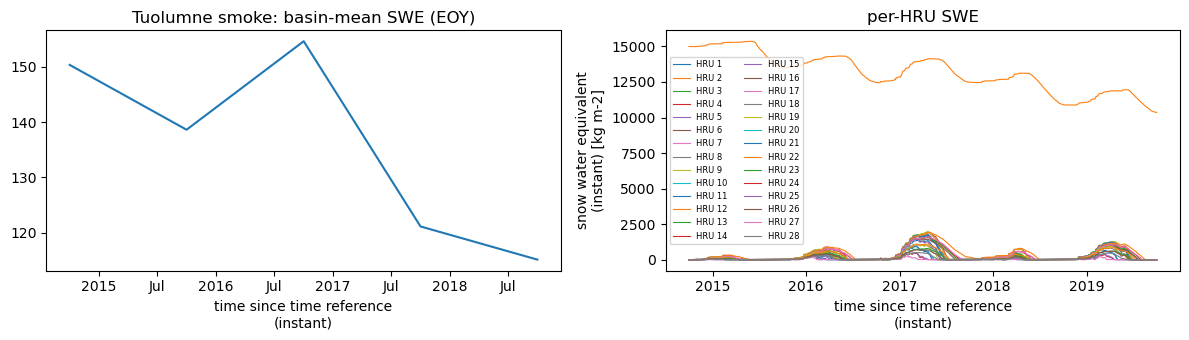

In [9]:
# inspect the smoke output: did the snowpack persist and feed melt?
# NOTE: load eagerly inside a `with` block so the netCDF handle is RELEASED — otherwise the
# kernel keeps the output file open and the next SUMMA run fails with def_output Permission denied.
if rc == 0:
    out = sorted((run/"output").glob("*timestep*.nc")) or sorted((run/"output").glob("*.nc"))
    with xr.open_dataset(out[0]) as ds:
        print("output vars:", [v for v in ds.data_vars][:20])
        swe_hru = ds["scalarSWE"].load()              # pull into memory -> safe to close file
    with xr.open_dataset(DOMAINS["Tuolumne"]["settings"]/"attributes.nc") as att:
        w = (att["HRUarea"]/att["HRUarea"].sum()).load()
    swe_eoy = swe_hru.resample(time="YS-OCT").last()  # end-of-water-year snapshot
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
    (swe_eoy*w).sum("hru").plot(ax=ax[0]); ax[0].set_title("Tuolumne smoke: basin-mean SWE (EOY)")
    for hru in swe_hru.hru:
        swe_hru.sel(hru=hru).plot(ax=ax[1], lw=0.8, label=f"HRU {int(hru)}")
    ax[1].set_title("per-HRU SWE"); ax[1].legend(fontsize=6, ncol=2)
    plt.tight_layout(); plt.show()
else:
    print("SUMMA failed — inspect tail of", run/"summa.log")
    print(subprocess.run(["tail","-30",str(run/"summa.log")],capture_output=True,text=True).stdout)

## 5 · Build the sweeps

Baseline member = `swe_m=0` / unperturbed aquifer. Toggle `RUN=True` to launch (serial here; port
to the `ThreadPoolExecutor` in `synthetic_extended_runs.py` for parallel).

In [ ]:
RUN = False   # flip to True to actually run SUMMA for every member

def sweep_tuolumne():
    exp = SCRATCH/DOMAINS["Tuolumne"]["data_dir"]/"simulations"/"store_memory_sandbox"
    tgt = [TUO_SNOWPATCH_HRU]                       # snow (and the albedo floor) go on this one HRU
    # ONE per-HRU albedo-floor trialParams, SHARED by every member so only initial snow mass varies.
    # None -> symlink the unmodified settings trialParams (NIR default 0.30 -> pack melts out).
    tp = None
    if TUO_ALBEDO_NIR_FLOOR is not None:
        tp = make_albedo_trial(DOMAINS["Tuolumne"]["settings"]/"trialParams.nc",
                               exp/"trial_albedofloor.nc", TUO_SNOWPATCH_HRU, TUO_ALBEDO_NIR_FLOOR)
    members = {}
    for swe in TUO_SWE_LEVELS_M:
        name = f"swe_{swe:04.1f}m"
        ws = inject_snowpatch(BASE["Tuolumne"], exp/f"ws_{name}.nc", tgt, swe_m=float(swe))
        run = build_member("Tuolumne", name, ws, trialparams=tp)
        members[name] = {"run": run, "swe_m": float(swe), "nir_floor": TUO_ALBEDO_NIR_FLOOR}
        if RUN: run_member(run)
    return members

def sweep_east():
    exp = SCRATCH/DOMAINS["East"]["data_dir"]/"simulations"/"store_memory_sandbox"
    base_trial = DOMAINS["East"]["settings"]/"trialParams.nc"
    members = {}
    for tau in EAST_TAU_DAYS:
        name = f"tau_{tau:05.0f}d"
        ws  = exp/f"ws_{name}.nc"; tp = exp/f"trial_{name}.nc"
        set_aquifer_memory(BASE["East"], base_trial, ws, tp,
                           target_hrus=EAST_FLAT_HRU, tau_days=float(tau), init_stor_m=EAST_INIT_STOR_M)
        run = build_member("East", name, ws, trialparams=tp)
        members[name] = {"run": run, "tau_days": float(tau)}
        if RUN: run_member(run)
    return members

TUO_MEMBERS  = sweep_tuolumne()
EAST_MEMBERS = sweep_east()
print(f"Built {len(TUO_MEMBERS)} Tuolumne + {len(EAST_MEMBERS)} East members "
      f"(RUN={RUN}, Tuolumne NIR floor={TUO_ALBEDO_NIR_FLOOR}).")

## 6 · Anomaly analysis

For each member, load routed streamflow, compute the anomaly vs. the baseline member, then extract:
- **peak late-season (JJAS) anomaly** vs. store size, per water year;
- the **e-folding decay** of the annual peak anomaly across WY2015→WY2019.

`load_flow` looks for `averageRoutedRunoff`/`scalarTotalRunoff` (area-weighted basin sum). Adjust the
variable/units to match your `outputControl.txt`.

In [ ]:
def load_flow(dom, run: Path) -> pd.Series:
    out = sorted((run/"output").glob("*timestep*.nc")) or sorted((run/"output").glob("*.nc"))
    if not out: return None
    ds = xr.open_dataset(out[0])
    var = next((v for v in ("averageRoutedRunoff","scalarTotalRunoff","scalarSurfaceRunoff") if v in ds), None)
    if var is None: ds.close(); return None
    att = xr.open_dataset(DOMAINS[dom]["settings"]/"attributes.nc")
    area = att["HRUarea"]
    q = (ds[var]*area).sum("hru")           # runoff-rate × area → volume flux
    s = q.to_series(); ds.close(); att.close()
    return s

def anomaly_table(dom, members, key):
    base = load_flow(dom, members[[m for m in members][0]]["run"])  # first = baseline (store=0/min)
    rows = []
    for name, meta in members.items():
        q = load_flow(dom, meta["run"])
        if q is None or base is None: continue
        a = (q - base)
        for wy, g in a.groupby(a.index.to_period("Y-SEP") if False else _water_year(a.index)):
            late = g[(g.index.month>=LATE_SEASON[0]) & (g.index.month<=LATE_SEASON[1])]
            rows.append({"member":name, key:meta[key], "wy":wy, "peak_anom":late.max(), "mean_anom":late.mean()})
    return pd.DataFrame(rows)

def _water_year(idx): return np.where(idx.month>=10, idx.year+1, idx.year)

# Example (after RUN=True and runs complete):
# dfT = anomaly_table("Tuolumne", TUO_MEMBERS, "swe_m")
# dfE = anomaly_table("East", EAST_MEMBERS, "tau_days")
# fig, ax = plt.subplots(1,2,figsize=(12,4))
# for wy,g in dfT.groupby("wy"): ax[0].plot(g["swe_m"], g["peak_anom"], "-o", label=f"WY{wy}")
# ax[0].set(xlabel="initial SWE (m)", ylabel="peak JJAS flow anomaly", title="Tuolumne"); ax[0].legend()
# for wy,g in dfE.groupby("wy"): ax[1].plot(g["tau_days"], g["peak_anom"], "-o", label=f"WY{wy}")
# ax[1].set(xscale="log", xlabel="aquifer tau (days)", ylabel="peak JJAS flow anomaly", title="East"); ax[1].legend()
# plt.tight_layout(); plt.show()
print("Analysis helpers ready — run the sweeps (RUN=True), then uncomment the example block.")

## 7 · Snowpatch split into depth bins — evolving snow area → interannual memory

A single snowpatch HRU melts out all-or-nothing, so its snow-covered *area* never changes. Splitting it
into sibling HRUs — **same** elevation / aspect / soil / veg / forcing, **different** initial SWE and area —
lets the shallow bins melt out first, so the covered area (and the aggregate melt) tapers: a sub-grid snow
depletion curve, with the deep bin's slow multi-year drawdown carrying the interannual memory.

Built by **cloning** the source HRU along the `hru` dimension of `attributes.nc`, `warmState.nc`,
`trialParams.nc`, and each monthly forcing file (mizuRoute is untouched — still one GRU, so a SUMMA-only run
suffices). Default: split Tuolumne hru 2 into deep 5 m / moderate 3 m / shallow 1 m over two water years.

In [ ]:
# ── snowpatch SPLIT experiment dials ─────────────────────────────────────────
SPLIT_SRC_HRU      = TUO_SNOWPATCH_HRU          # HRU to split (Tuolumne hru 2)
SPLIT_BIN_HRUS     = [SPLIT_SRC_HRU, 29, 30]    # hruIds for the bins; source is reused as bin 0 (deep)
SPLIT_BIN_ROLES    = ["deep", "moderate", "shallow"]
SPLIT_BIN_SWE      = [5.0, 3.0, 1.0]            # initial SWE per bin (m water-equiv)
SPLIT_AREA_WEIGHTS = [1/3, 1/3, 1/3]            # fraction of the source-HRU area per bin (must sum to 1)
SPLIT_SIM_START    = "2014-10-01 00:00"
SPLIT_SIM_END      = "2016-09-30 23:00"         # two water years for the proof-of-concept
SPLIT_MONTHS       = pd.date_range(SPLIT_SIM_START[:7] + "-01", SPLIT_SIM_END[:7] + "-01", freq="MS")
assert abs(sum(SPLIT_AREA_WEIGHTS) - 1) < 1e-9, "SPLIT_AREA_WEIGHTS must sum to 1"
assert len(SPLIT_BIN_HRUS) == len(SPLIT_BIN_SWE) == len(SPLIT_AREA_WEIGHTS) == len(SPLIT_BIN_ROLES)
print("split bins:", list(zip(SPLIT_BIN_ROLES, SPLIT_BIN_HRUS, SPLIT_BIN_SWE)),
      "\nperiod:", SPLIT_SIM_START, "->", SPLIT_SIM_END, f"({len(SPLIT_MONTHS)} months)")

In [ ]:
def clone_hru_along(nc_in: Path, nc_out: Path, src_id, new_ids, area_split=None) -> Path:
    """Copy a netCDF, appending clones of hru `src_id` (as `new_ids`) along the hru dim. Works for
    attributes / warmState / trialParams / forcing alike. `area_split` = {hruId: fraction} rescales
    HRUarea of those hruIds to fraction*<source area> (used to divide the split HRU's area).
    GOTCHA: forcing vars carry _FillValue, which must be set at createVariable time -> pass fill_value."""
    din = nc4.Dataset(nc_in); hid = np.array(din["hruId"][:]).ravel(); n_old = hid.size
    si = int(np.where(hid == src_id)[0][0])
    with nc4.Dataset(nc_out, "w") as d:
        for nm, dim in din.dimensions.items():
            d.createDimension(nm, n_old + len(new_ids) if nm == "hru"
                              else (None if dim.isunlimited() else len(dim)))
        for nm, var in din.variables.items():
            fv = var.getncattr("_FillValue") if "_FillValue" in var.ncattrs() else None
            v = d.createVariable(nm, var.datatype, var.dimensions, fill_value=fv)
            for a in var.ncattrs():
                if a != "_FillValue": v.setncattr(a, var.getncattr(a))
            arr = np.array(var[:])
            if "hru" in var.dimensions:                                  # replicate the source column
                ax = var.dimensions.index("hru")
                arr = np.concatenate([arr, np.take(arr, [si] * len(new_ids), axis=ax)], axis=ax)
            v[:] = arr
        hid2 = np.array(d["hruId"][:]).ravel()
        for k, nid in enumerate(new_ids): hid2[n_old + k] = nid           # fix clone hruIds
        d["hruId"][:] = hid2
        if area_split and "HRUarea" in d.variables:
            area = np.array(d["HRUarea"][:]).ravel(); src_area = area[np.where(hid2 == src_id)[0][0]]
            for h, frac in area_split.items(): area[np.where(hid2 == h)[0][0]] = frac * src_area
            d["HRUarea"][:] = area
    din.close(); return nc_out


def inject_multi(base_ws: Path, out_ws: Path, swe_by_hru) -> Path:
    """Like inject_snowpatch but a DIFFERENT SWE per HRU: swe_by_hru = {hruId: metres}. Prepends
    SNOW_N_LAYERS snow layers on each listed HRU and sets cold ground (SNOWPATCH_SOIL_TEMP_K) under it."""
    src = nc4.Dataset(base_ws); hid = np.array(src["hruId"][:]).ravel(); nhru = hid.size
    nsoil = int(np.array(src["nSoil"][:]).ravel()[0])
    swe_mm = np.zeros(nhru)
    for h, m in swe_by_hru.items(): swe_mm[hid == h] = m * 1000.0
    nsnow = np.where(swe_mm > 0, SNOW_N_LAYERS, 0).astype("i4")
    nmid = int(nsnow.max()) + nsoil; nifc = nmid + 1
    def soil(nm):
        a = np.atleast_2d(np.array(src[nm][:])); return (a if a.shape[1] == nhru else a.T)[:nsoil].copy()
    sT, sIce, sLiq, sDep, matric = (soil("mLayerTemp"), soil("mLayerVolFracIce"),
                                    soil("mLayerVolFracLiq"), soil("mLayerDepth"), soil("mLayerMatricHead"))
    if SNOWPATCH_SOIL_TEMP_K is not None:
        sT[:, swe_mm > 0] = SNOWPATCH_SOIL_TEMP_K                          # cold ground under every bin
    T = np.zeros((nmid, nhru)); Ice = np.zeros((nmid, nhru)); Liq = np.zeros((nmid, nhru))
    Dep = np.zeros((nmid, nhru)); iH = np.zeros((nifc, nhru))
    for h in range(nhru):
        ns = int(nsnow[h])
        if ns:
            dtot = swe_mm[h] / SNOW_DENSITY
            T[:ns, h] = SNOW_TEMP_K; Ice[:ns, h] = SNOW_DENSITY / RHO_ICE; Dep[:ns, h] = dtot / ns
        T[ns:ns+nsoil, h] = sT[:, h]; Ice[ns:ns+nsoil, h] = sIce[:, h]
        Liq[ns:ns+nsoil, h] = sLiq[:, h]; Dep[ns:ns+nsoil, h] = sDep[:, h]
        dep = Dep[:ns+nsoil, h]
        iH[:ns+nsoil+1, h] = -dep[:ns].sum() + np.concatenate([[0.0], np.cumsum(dep)])
    with nc4.Dataset(out_ws, "w") as d:
        for n, s in [("hru",nhru),("scalarv",1),("midSoil",nsoil),("midToto",nmid),("ifcToto",nifc)]:
            d.createDimension(n, s)
        d.createVariable("hruId","i4",("hru",))[:] = hid
        d.createVariable("nSoil","i4",("scalarv","hru"))[:] = nsoil
        d.createVariable("nSnow","i4",("scalarv","hru"))[0,:] = nsnow
        d.createVariable("dt_init","f8",("scalarv","hru"))[:] = 3600.0
        for nm in ["scalarCanopyIce","scalarCanopyLiq","scalarSfcMeltPond",
                   "scalarAquiferStorage","scalarCanopyTemp","scalarCanairTemp"]:
            d.createVariable(nm,"f8",("scalarv","hru"))[0,:] = np.array(src[nm][:]).ravel()
        swe_v = np.array(src["scalarSWE"][:]).ravel(); dep_v = np.array(src["scalarSnowDepth"][:]).ravel()
        alb_v = np.array(src["scalarSnowAlbedo"][:]).ravel()
        for h, m in swe_by_hru.items():
            swe_v[hid == h] = m * 1000.0; dep_v[hid == h] = m * 1000.0 / SNOW_DENSITY; alb_v[hid == h] = 0.60
        d.createVariable("scalarSWE","f8",("scalarv","hru"))[0,:] = swe_v
        d.createVariable("scalarSnowDepth","f8",("scalarv","hru"))[0,:] = dep_v
        d.createVariable("scalarSnowAlbedo","f8",("scalarv","hru"))[0,:] = alb_v
        d.createVariable("mLayerTemp","f8",("midToto","hru"))[:] = T
        d.createVariable("mLayerVolFracIce","f8",("midToto","hru"))[:] = Ice
        d.createVariable("mLayerVolFracLiq","f8",("midToto","hru"))[:] = Liq
        d.createVariable("mLayerDepth","f8",("midToto","hru"))[:] = Dep
        d.createVariable("mLayerMatricHead","f8",("midSoil","hru"))[:] = matric
        d.createVariable("iLayerHeight","f8",("ifcToto","hru"))[:] = iH
    src.close(); return out_ws

In [ ]:
def build_split_member(name="split_bins") -> Path:
    """Assemble a Tuolumne member with the source HRU split into len(SPLIT_BIN_HRUS) depth bins:
    split attributes / warmState / trialParams / forcing, inject per-bin SWE, apply the albedo floor
    to every bin, write fileManager. Returns the run dir. Needs SUMMA only (mizuRoute unchanged)."""
    dom = "Tuolumne"; cfg = DOMAINS[dom]; sett = cfg["settings"]
    exp = SCRATCH/cfg["data_dir"]/"simulations"/"store_memory_sandbox"/"split"
    run = exp/name; (run/"output").mkdir(parents=True, exist_ok=True)
    forc = exp/(name + "_forcing"); forc.mkdir(parents=True, exist_ok=True)
    added = SPLIT_BIN_HRUS[1:]                                    # clones to append (source stays)
    area_split = dict(zip(SPLIT_BIN_HRUS, SPLIT_AREA_WEIGHTS))
    # 1) attributes — 30-HRU, source area divided across the bins
    clone_hru_along(sett/"attributes.nc", run/"attributes.nc", SPLIT_SRC_HRU, added, area_split=area_split)
    # 2) warm state — 28-HRU extract -> clone to bins -> inject per-bin SWE (+ cold ground)
    base28 = exp/"base28_warmState.nc"; extract_warmstate(cfg["longterm"], sett/"coldState.nc", base28)
    base30 = exp/"base30_warmState.nc"; clone_hru_along(base28, base30, SPLIT_SRC_HRU, added)
    inject_multi(base30, run/"warmState.nc", dict(zip(SPLIT_BIN_HRUS, SPLIT_BIN_SWE)))
    # 3) trialParams — clone params, then albedo floor on every bin
    clone_hru_along(sett/"trialParams.nc", run/"trialParams.nc", SPLIT_SRC_HRU, added)
    if TUO_ALBEDO_NIR_FLOOR is not None:
        with nc4.Dataset(run/"trialParams.nc", "a") as t:
            hid = np.array(t["hruId"][:]).ravel(); m = np.isin(hid, SPLIT_BIN_HRUS)
            v = (t.createVariable("albedoMinNearIR","f8",("hru",))
                 if "albedoMinNearIR" not in t.variables else t["albedoMinNearIR"])
            v[:] = np.where(m, TUO_ALBEDO_NIR_FLOOR, TUO_ALBEDO_NIR_DEFAULT)
    # 4) forcing — clone hru column into each monthly file for the period
    pre = forcing_prefix(dom)
    for d0 in SPLIT_MONTHS:
        fn = f"{pre}{d0.year:04d}{d0.month:02d}.nc"
        clone_hru_along(cfg["forcing"]/fn, forc/fn, SPLIT_SRC_HRU, added)
    # 5) settings symlinks (keep the real 30-HRU attributes) + fileManager
    for fn in SETTINGS_LINK:
        if fn == "attributes.nc": continue
        dst = run/fn
        if dst.is_symlink() or dst.exists(): dst.unlink()
        if (sett/fn).exists(): dst.symlink_to((sett/fn).resolve())
    tmzone = "localTime"
    for ln in (sett/"fileManager.txt").read_text().splitlines():
        if ln.strip().startswith("tmZoneInfo"): tmzone = ln.split("'")[1]; break
    (run/"forcingFileList.txt").write_text("".join(f"{pre}{d0.year:04d}{d0.month:02d}.nc\n" for d0 in SPLIT_MONTHS))
    (run/"fileManager.txt").write_text(
        "controlVersion       'SUMMA_FILE_MANAGER_V3.0.0'\n"
        f"simStartTime         '{SPLIT_SIM_START}'\n"
        f"simEndTime           '{SPLIT_SIM_END}'\n"
        f"tmZoneInfo           '{tmzone}'\n"
        f"outFilePrefix        'split_{name}'\n"
        f"settingsPath         '{run}/'\n"
        f"forcingPath          '{forc}/'\n"
        f"outputPath           '{run}/output/'\n"
        "initConditionFile    'warmState.nc'\n"
        "attributeFile        'attributes.nc'\n"
        "trialParamFile       'trialParams.nc'\n"
        "forcingListFile      'forcingFileList.txt'\n"
        "decisionsFile        'modelDecisions.txt'\n"
        "outputControlFile    'outputControl.txt'\n"
        "globalHruParamFile   'localParamInfo.txt'\n"
        "globalGruParamFile   'basinParamInfo.txt'\n"
        "vegTableFile         'TBL_VEGPARM.TBL'\n"
        "soilTableFile        'TBL_SOILPARM.TBL'\n"
        "generalTableFile     'TBL_GENPARM.TBL'\n"
        "noahmpTableFile      'TBL_MPTABLE.TBL'\n")
    _a = nc4.Dataset(run/"attributes.nc"); _h = np.array(_a["hruId"][:]).ravel()
    _ar = np.array(_a["HRUarea"][:]).ravel(); _a.close()
    print(f"built split member: {_h.size} HRUs | bin areas km2:",
          {r: round(_ar[_h == h][0]/1e6, 2) for r, h in zip(SPLIT_BIN_ROLES, SPLIT_BIN_HRUS)})
    return run

RUN_SPLIT = False   # flip to True to run SUMMA on the split member (~2 min for 2 water years)
split_run = build_split_member()
if RUN_SPLIT: run_member(split_run)

In [ ]:
# Late-season decay of the depth-bin stores: init -> Sep 30 of each water year, plus the
# area-weighted aggregate (the memory signal). Needs the split member to have run (RUN_SPLIT=True).
_out = sorted((split_run/"output").glob("*timestep*.nc")) or sorted((split_run/"output").glob("*.nc"))
if not _out:
    print("no split output yet — set RUN_SPLIT=True and re-run the build cell above")
else:
    with xr.open_dataset(_out[0]) as _ds:
        _hid = np.array(_ds["hruId"].values).ravel() if "hruId" in _ds else np.array(_ds["hru"].values).ravel()
        swe_bins = {h: (_ds["scalarSWE"].isel(hru=int(np.where(_hid == h)[0][0])).to_series() / 1000.0)
                    for h in SPLIT_BIN_HRUS}
    with xr.open_dataset(split_run/"attributes.nc") as _at:
        _ah = np.array(_at["hruId"].values).ravel()
        bin_area = {h: float(_at["HRUarea"].values.ravel()[_ah == h][0]) for h in SPLIT_BIN_HRUS}
    colors = ["#08306b", "#4292c6", "#9ecae1"]                      # deep -> shallow (sequential blue)
    sep30 = [pd.Timestamp(f"{y}-09-30") for y in range(int(SPLIT_SIM_START[:4]) + 1, int(SPLIT_SIM_END[:4]) + 1)]
    fig, axs = plt.subplots(1, 2, figsize=(12, 4.2))
    agg = None; patch_area = sum(bin_area.values())
    for h, role, color, swe0 in zip(SPLIT_BIN_HRUS, SPLIT_BIN_ROLES, colors, SPLIT_BIN_SWE):
        s = swe_bins[h]
        axs[0].plot(s.index, s.values, color=color, lw=2, label=f"{role} (hru {h}), init {swe0:.0f} m")
        for mk in sep30:                                            # mark each Sep-30 late-season floor
            val = s.iloc[np.abs((s.index - mk).to_numpy()).argmin()]
            axs[0].plot(mk, val, "o", color=color, ms=6, zorder=5)
            axs[0].annotate(f"{val:.2f}", (mk, val), textcoords="offset points", xytext=(6, 4),
                            fontsize=8, color=color, weight="bold")
        agg = s * bin_area[h] if agg is None else agg + s * bin_area[h]
    for mk in sep30: axs[0].axvline(mk, color="0.7", lw=0.8, ls=":")
    axs[0].set(xlabel="date", ylabel="bin SWE (m w.e.)", title="(a) depth-bin stores decaying to each Sep 30")
    axs[0].legend(frameon=False, fontsize=8)
    (agg / patch_area).plot(ax=axs[1], color="#D55E00", lw=2.4)
    axs[1].set(xlabel="date", ylabel="area-mean SWE over patch (m w.e.)",
               title="(b) area-weighted aggregate = memory signal")
    for a in axs: a.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()
    print("Sep-30 late-season floors (m):")
    for h, role in zip(SPLIT_BIN_HRUS, SPLIT_BIN_ROLES):
        s = swe_bins[h]
        print(f"  {role:8s}:", {mk.year: round(float(s.iloc[np.abs((s.index - mk).to_numpy()).argmin()]), 2)
                                for mk in sep30})